# BÀI TẬP 4.3 - Gom cụm văn bản với KMean

---

**Họ và tên:** Nguyễn Quang Linh
**MSSV:** 038205003016

---

## 1: Tải dữ liệu và Tiền xử lý (Vectorization)

In [28]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Định nghĩa các nhóm tin và tải dữ liệu
categories = ['sci.space', 'soc.religion.christian', 'talk.politics.guns']
data = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))

# 2. Chuyển đổi văn bản thành vector TF-IDF
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
X = vectorizer.fit_transform(data.data)
y_true = data.target

print(f"Kích thước ma trận dữ liệu: {X.shape}")


Kích thước ma trận dữ liệu: (2894, 2000)


### 2: Thực hiện gom cụm bằng K-Means

In [29]:
from sklearn.cluster import KMeans
## vì có 3 nhóm nên chọn K = 3
# Khởi tạo và huấn luyện mô hình
k = 3
model = KMeans(n_clusters=k, init='k-means++', max_iter=100, n_init=10, random_state=42)
model.fit(X)

# Lấy nhãn dự đoán từ mô hình
labels = model.labels_
print("Hoàn tất gom cụm.")

Hoàn tất gom cụm.


## 3: Đánh giá kết quả gom cụm

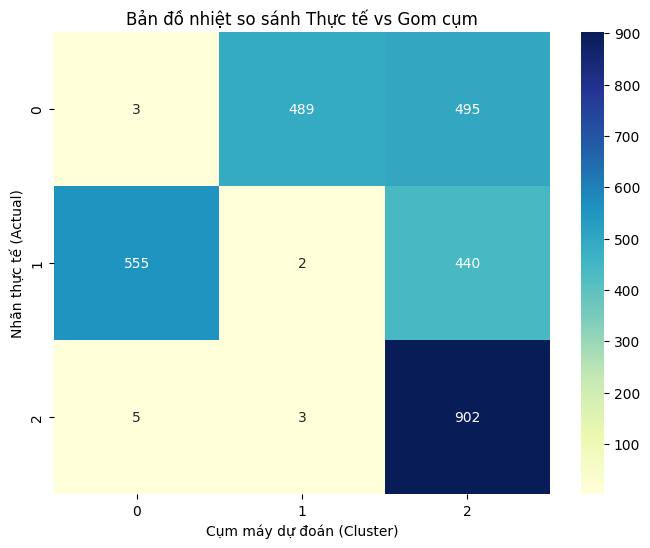

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# Giả sử bạn đã có biến df_eval từ cell trước
confusion_matrix = pd.crosstab(df_eval['Actual'], df_eval['Cluster'])

plt.figure(figsize=(8, 6))
# Vẽ Heatmap
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='YlGnBu', cbar=True)

plt.title('Bản đồ nhiệt so sánh Thực tế vs Gom cụm')
plt.xlabel('Cụm máy dự đoán (Cluster)')
plt.ylabel('Nhãn thực tế (Actual)')
plt.show()

## 4: Trực quan hóa dữ liệu bằng PCA

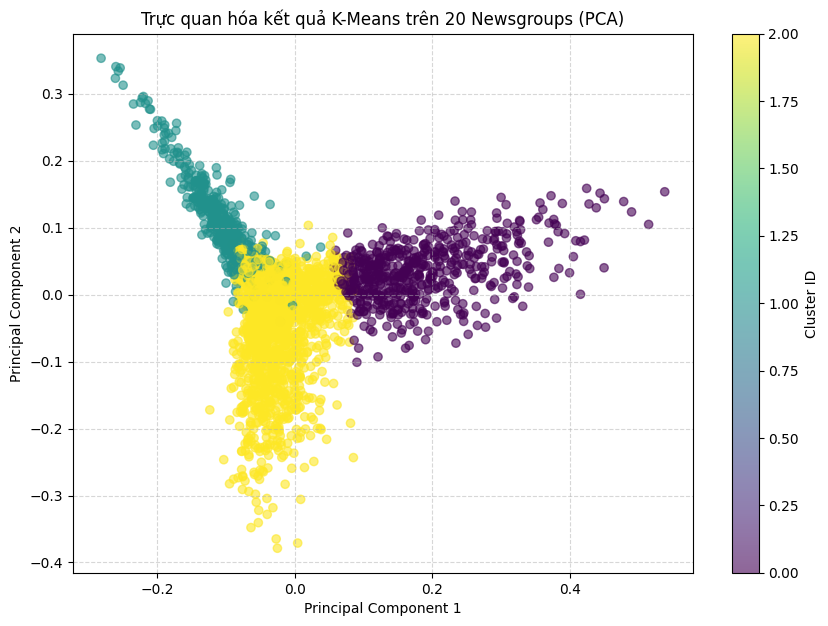

In [31]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Giảm chiều dữ liệu về 2D
pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X.toarray())

# Vẽ đồ thị
plt.figure(figsize=(10, 7))
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'

# Vẽ các điểm theo nhãn đã gom cụm
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')

plt.title("Trực quan hóa kết quả K-Means trên 20 Newsgroups (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()